## Davis Southern Women Social Network
#### Data 620: Assignment Week 6
#### Maxfield Raynolds
#### Spring 2026

The Davis Southern Women Social Network is a dataset collected in the 1930s that tracks 18 women's attendance at 14 social events. The code below works to analyze this network and draw some inferences about the attendees.

#### Project Video:

[Data 620 Assignment Week 6 Video]('https://youtu.be/PMqecpjooD4')

First load packages:

In [28]:
# load packages

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from networkx.algorithms import bipartite
from networkx.algorithms.community import greedy_modularity_communities

Then load the data:

In [29]:
B = nx.davis_southern_women_graph()
print(type(B))
print(nx.is_bipartite(B))

<class 'networkx.classes.graph.Graph'>
True


A look at the nodes:

In [30]:
B.nodes

NodeView(('Evelyn Jefferson', 'Laura Mandeville', 'Theresa Anderson', 'Brenda Rogers', 'Charlotte McDowd', 'Frances Anderson', 'Eleanor Nye', 'Pearl Oglethorpe', 'Ruth DeSand', 'Verne Sanderson', 'Myra Liddel', 'Katherina Rogers', 'Sylvia Avondale', 'Nora Fayette', 'Helen Lloyd', 'Dorothy Murchison', 'Olivia Carleton', 'Flora Price', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14'))

In [31]:
full_diameter = nx.diameter(B)
full_diameter

4

### The Network

A look at the network:

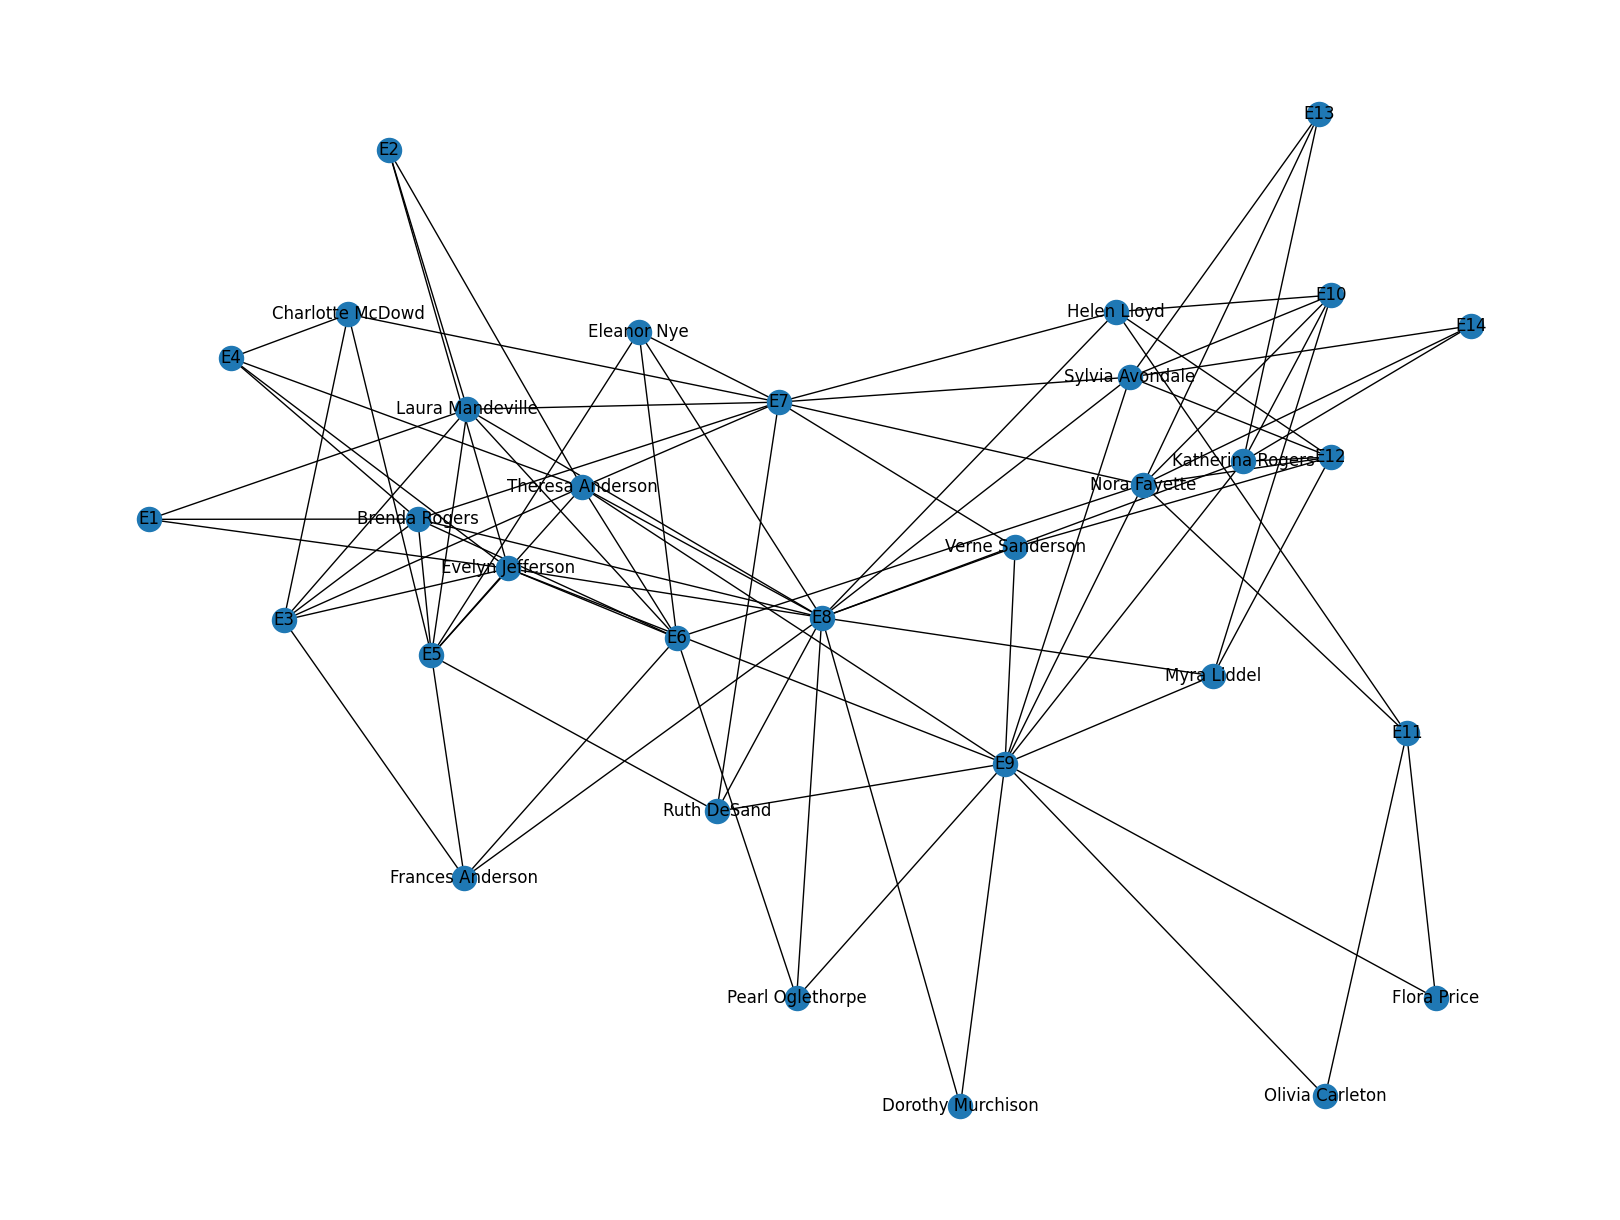

In [32]:
plt.figure(figsize=(16,12))
pos = nx.spring_layout(B, seed=1234)

nx.draw(B, with_labels=True, pos = pos)

plt.show()

The shape of the network appears to indicate a couple things.
- Two connected but largely separate groups of events and attendees
- Events E6, E7, E8 appear to be the primary connection between these two groups.

The next step is to project the people and events into two spearate lists.

In [33]:
women = []
event = []

for n,d in B.nodes(data=True):
    if d['bipartite'] == 0:
        women.append(n)
    else:
        event.append(n)

In [34]:
women

['Evelyn Jefferson',
 'Laura Mandeville',
 'Theresa Anderson',
 'Brenda Rogers',
 'Charlotte McDowd',
 'Frances Anderson',
 'Eleanor Nye',
 'Pearl Oglethorpe',
 'Ruth DeSand',
 'Verne Sanderson',
 'Myra Liddel',
 'Katherina Rogers',
 'Sylvia Avondale',
 'Nora Fayette',
 'Helen Lloyd',
 'Dorothy Murchison',
 'Olivia Carleton',
 'Flora Price']

Some facts about the network:

In [35]:
print(f'Total women in the network: {len(women)}')
print(f'Total events in the network: {len(event)}')
print(f'Total nodes: {B.number_of_nodes()}')
print(f'Total edges: {B.number_of_edges()}')

Total women in the network: 18
Total events in the network: 14
Total nodes: 32
Total edges: 89


A calculation of the bipartite density of the network. There are 89 edges in the network and a total possible number of edges is 252. This yields the density below:

In [36]:
bipartite.density(B, women)

0.3531746031746032

### Biadjacency Matrix

Below is the biadjacency matrix of the women and the events they attended with a column to calculate how many events each woman attended and a row for how many women attended each event.

In [37]:
matrix = bipartite.biadjacency_matrix(B, row_order = women, column_order = event)

matrix_df = pd.DataFrame(
    matrix.toarray(),
    index = women,
    columns = event
)

matrix_df['Total'] = matrix_df.sum(axis = 1)
column_sums = matrix_df.sum(numeric_only=True)
matrix_df.loc['Total'] = column_sums

matrix_df

,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,E13,E14,Total
Evelyn Jefferson,1,1,1,1,1,1,0,1,1,0,0,0,0,0,8
Laura Mandeville,1,1,1,0,1,1,1,1,0,0,0,0,0,0,7
Theresa Anderson,0,1,1,1,1,1,1,1,1,0,0,0,0,0,8
Brenda Rogers,1,0,1,1,1,1,1,1,0,0,0,0,0,0,7
Charlotte McDowd,0,0,1,1,1,0,1,0,0,0,0,0,0,0,4
Frances Anderson,0,0,1,0,1,1,0,1,0,0,0,0,0,0,4
Eleanor Nye,0,0,0,0,1,1,1,1,0,0,0,0,0,0,4
Pearl Oglethorpe,0,0,0,0,0,1,0,1,1,0,0,0,0,0,3
Ruth DeSand,0,0,0,0,1,0,1,1,1,0,0,0,0,0,4
Verne Sanderson,0,0,0,0,0,0,1,1,1,0,0,1,0,0,4


Looking at the biadjacency matrix there are a few pieces of information that can be gleaned:

- Only three events had the majority of women attend them: E7, E8, E9
- Only three women attended more than half of the events: Evelyn Jefferson, Theresa Anderson, and Nora Fayette.
- The attendance seems to be in a diagonal pattern, indicating that the first ~half of the women attended most of the same events and the second ~half of the women attended most of the same events.

### Centrality Measures

#### The Women
Calculate the degree of centrality for the women. This is the same values observed in the biadjacency matrix.

In [38]:
sorted(B.degree(women), key = lambda x:x[1], reverse = True)

[('Evelyn Jefferson', 8),
 ('Theresa Anderson', 8),
 ('Nora Fayette', 8),
 ('Laura Mandeville', 7),
 ('Brenda Rogers', 7),
 ('Sylvia Avondale', 7),
 ('Katherina Rogers', 6),
 ('Helen Lloyd', 5),
 ('Charlotte McDowd', 4),
 ('Frances Anderson', 4),
 ('Eleanor Nye', 4),
 ('Ruth DeSand', 4),
 ('Verne Sanderson', 4),
 ('Myra Liddel', 4),
 ('Pearl Oglethorpe', 3),
 ('Dorothy Murchison', 2),
 ('Olivia Carleton', 2),
 ('Flora Price', 2)]

Then the degree centrality for the events. This is the same as the values observed in the biadjacency matrix.

In [39]:
sorted(B.degree(event), key = lambda x:x[1], reverse = True)

[('E8', 14),
 ('E9', 12),
 ('E7', 10),
 ('E5', 8),
 ('E6', 8),
 ('E3', 6),
 ('E12', 6),
 ('E10', 5),
 ('E4', 4),
 ('E11', 4),
 ('E1', 3),
 ('E2', 3),
 ('E13', 3),
 ('E14', 3)]

The following code creates a weighted projected graph object for the women in the original bipartite network graph object. This will allow for more mneaningful centrality measures to be calculated.

In [40]:
W = bipartite.weighted_projected_graph(B, women)
E = bipartite.weighted_projected_graph(B, event)

The degree below shows a different result than when unweighted. An interesting observation is that, "higher degree" women generally attended the very well attended events mentioned earlier.

In [41]:
diameter = nx.diameter(W)

print(f'The network diameter is: {diameter}')

The network diameter is: 2


In [42]:
sorted(W.degree(women), key = lambda x:x[1], reverse = True)

[('Evelyn Jefferson', 17),
 ('Theresa Anderson', 17),
 ('Ruth DeSand', 17),
 ('Verne Sanderson', 17),
 ('Sylvia Avondale', 17),
 ('Nora Fayette', 17),
 ('Helen Lloyd', 17),
 ('Pearl Oglethorpe', 16),
 ('Myra Liddel', 16),
 ('Katherina Rogers', 16),
 ('Dorothy Murchison', 16),
 ('Laura Mandeville', 15),
 ('Brenda Rogers', 15),
 ('Frances Anderson', 15),
 ('Eleanor Nye', 15),
 ('Olivia Carleton', 12),
 ('Flora Price', 12),
 ('Charlotte McDowd', 11)]

The function below will help sort the results of the remaining centrality metrics:

In [43]:
def sorted_map(d):
    return sorted(d.items(), key = lambda item: (-item[1],item[0]))

The results of degree centrality below indicates that seven women attended events with all other women. There is generally a high degree of centrality.

In [44]:
sorted_map(nx.degree_centrality(W))

[('Evelyn Jefferson', 1.0),
 ('Helen Lloyd', 1.0),
 ('Nora Fayette', 1.0),
 ('Ruth DeSand', 1.0),
 ('Sylvia Avondale', 1.0),
 ('Theresa Anderson', 1.0),
 ('Verne Sanderson', 1.0),
 ('Dorothy Murchison', 0.9411764705882353),
 ('Katherina Rogers', 0.9411764705882353),
 ('Myra Liddel', 0.9411764705882353),
 ('Pearl Oglethorpe', 0.9411764705882353),
 ('Brenda Rogers', 0.8823529411764706),
 ('Eleanor Nye', 0.8823529411764706),
 ('Frances Anderson', 0.8823529411764706),
 ('Laura Mandeville', 0.8823529411764706),
 ('Flora Price', 0.7058823529411764),
 ('Olivia Carleton', 0.7058823529411764),
 ('Charlotte McDowd', 0.6470588235294118)]

The clustering below shows that the women have a relatively tight range of clustering from 0.372 to 0.258. This indicates that each woman often attends events that overlap with other women in the group, but that the overlap is moderate rather than complete.

In [45]:
sorted_map(bipartite.clustering(B, women))

[('Theresa Anderson', 0.3718188674071026),
 ('Brenda Rogers', 0.364912494912495),
 ('Ruth DeSand', 0.36435574229691875),
 ('Eleanor Nye', 0.3603174603174603),
 ('Laura Mandeville', 0.3518172568172569),
 ('Verne Sanderson', 0.34883286647992534),
 ('Pearl Oglethorpe', 0.3323412698412699),
 ('Myra Liddel', 0.3244047619047619),
 ('Sylvia Avondale', 0.32275192128133307),
 ('Evelyn Jefferson', 0.3179433311786253),
 ('Frances Anderson', 0.31481721981721983),
 ('Dorothy Murchison', 0.30500992063492055),
 ('Katherina Rogers', 0.29749503968253965),
 ('Charlotte McDowd', 0.2944116489571035),
 ('Helen Lloyd', 0.2616989219930396),
 ('Nora Fayette', 0.26057667822373703),
 ('Flora Price', 0.25750661375661377),
 ('Olivia Carleton', 0.2575066137566137)]

For betweenness centrality the results are fairly low. This is related to how short the diameter is and how high the degree centrality is. In general a node will not be on the shortest path between two other nodes when the many of the nodes are directly connected.

In [46]:
sorted_map(nx.betweenness_centrality(W))

[('Evelyn Jefferson', 0.010122230710466005),
 ('Helen Lloyd', 0.010122230710466005),
 ('Nora Fayette', 0.010122230710466005),
 ('Ruth DeSand', 0.010122230710466005),
 ('Sylvia Avondale', 0.010122230710466005),
 ('Theresa Anderson', 0.010122230710466005),
 ('Verne Sanderson', 0.010122230710466005),
 ('Dorothy Murchison', 0.0053475935828877),
 ('Katherina Rogers', 0.0053475935828877),
 ('Myra Liddel', 0.0053475935828877),
 ('Pearl Oglethorpe', 0.0053475935828877),
 ('Brenda Rogers', 0.0026737967914438505),
 ('Eleanor Nye', 0.0026737967914438505),
 ('Frances Anderson', 0.0026737967914438505),
 ('Laura Mandeville', 0.0026737967914438505),
 ('Charlotte McDowd', 0.0),
 ('Flora Price', 0.0),
 ('Olivia Carleton', 0.0)]

Interestingly, for eignevector centrality the well-connected women are close to the other well connected women.

In [56]:
sorted_map(nx.eigenvector_centrality(W))

[('Evelyn Jefferson', 0.2535242050574115),
 ('Theresa Anderson', 0.2535242050574115),
 ('Helen Lloyd', 0.25352420505741147),
 ('Nora Fayette', 0.25352420505741147),
 ('Ruth DeSand', 0.25352420505741147),
 ('Sylvia Avondale', 0.25352420505741147),
 ('Verne Sanderson', 0.25352420505741147),
 ('Dorothy Murchison', 0.24315691598127512),
 ('Katherina Rogers', 0.24315691598127512),
 ('Myra Liddel', 0.24315691598127512),
 ('Pearl Oglethorpe', 0.24315691598127512),
 ('Brenda Rogers', 0.2309732711453131),
 ('Eleanor Nye', 0.2309732711453131),
 ('Frances Anderson', 0.2309732711453131),
 ('Laura Mandeville', 0.2309732711453131),
 ('Flora Price', 0.18763937054214486),
 ('Olivia Carleton', 0.18763937054214486),
 ('Charlotte McDowd', 0.17252687994275986)]

### Centrality measures

#### The Events

Degree for events show that E6, E7, E8, E9 all have a higher degree than the other events. Interestingly their degree is equal at 13, while the degree for all other evnts was 8.

In [47]:
sorted(E.degree(event), key = lambda x:x[1], reverse = True)

[('E6', 13),
 ('E7', 13),
 ('E8', 13),
 ('E9', 13),
 ('E1', 8),
 ('E2', 8),
 ('E3', 8),
 ('E4', 8),
 ('E5', 8),
 ('E10', 8),
 ('E11', 8),
 ('E12', 8),
 ('E13', 8),
 ('E14', 8)]

Degree centrality show the same results as the degree did. E6, E7, E8, E9 are all connected directly to all other events. While the other events are all connected to 61% of the events.

In [55]:
sorted_map(nx.degree_centrality(E))

[('E6', 1.0),
 ('E7', 1.0),
 ('E8', 1.0),
 ('E9', 1.0),
 ('E1', 0.6153846153846154),
 ('E10', 0.6153846153846154),
 ('E11', 0.6153846153846154),
 ('E12', 0.6153846153846154),
 ('E13', 0.6153846153846154),
 ('E14', 0.6153846153846154),
 ('E2', 0.6153846153846154),
 ('E3', 0.6153846153846154),
 ('E4', 0.6153846153846154),
 ('E5', 0.6153846153846154)]

For betweenness centrality it is clear the events E6, E7, E8, E9 are equally central for betweenness and connect all the other events, which have a 0.0 betweenness centrality.

In [57]:
sorted_map(nx.betweenness_centrality(E))

[('E6', 0.08012820512820512),
 ('E7', 0.08012820512820512),
 ('E8', 0.08012820512820512),
 ('E9', 0.08012820512820512),
 ('E1', 0.0),
 ('E10', 0.0),
 ('E11', 0.0),
 ('E12', 0.0),
 ('E13', 0.0),
 ('E14', 0.0),
 ('E2', 0.0),
 ('E3', 0.0),
 ('E4', 0.0),
 ('E5', 0.0)]

In a similar way to the eigenvector centrality for the women, the group of well attended events are also the ones closest to central events.

In [58]:
sorted_map(nx.eigenvector_centrality(E))

[('E6', 0.3393355092231299),
 ('E7', 0.3393355092231299),
 ('E8', 0.3393355092231299),
 ('E9', 0.3393355092231299),
 ('E1', 0.23225108153055318),
 ('E10', 0.23225108153055318),
 ('E11', 0.23225108153055318),
 ('E12', 0.23225108153055318),
 ('E13', 0.23225108153055318),
 ('E14', 0.23225108153055318),
 ('E2', 0.23225108153055318),
 ('E3', 0.23225108153055318),
 ('E4', 0.23225108153055318),
 ('E5', 0.23225108153055318)]

## Communities

Below the data is explored through community based testing.

In [48]:
communities = greedy_modularity_communities(W)
communities

[frozenset({'Dorothy Murchison',
            'Evelyn Jefferson',
            'Flora Price',
            'Helen Lloyd',
            'Katherina Rogers',
            'Myra Liddel',
            'Nora Fayette',
            'Olivia Carleton',
            'Pearl Oglethorpe',
            'Ruth DeSand',
            'Sylvia Avondale',
            'Theresa Anderson'}),
 frozenset({'Brenda Rogers',
            'Charlotte McDowd',
            'Eleanor Nye',
            'Frances Anderson',
            'Laura Mandeville',
            'Verne Sanderson'})]

In [49]:
community_map = {}

for n, comm in enumerate(communities):
    for woman in comm:
        community_map[woman] = n + 1

df_community = pd.DataFrame(community_map.items(), columns = ['woman', 'community'])

df_community

,woman,community
0,Ruth DeSand,1
1,Olivia Carleton,1
2,Sylvia Avondale,1
3,Katherina Rogers,1
4,Dorothy Murchison,1
5,Theresa Anderson,1
6,Myra Liddel,1
7,Evelyn Jefferson,1
8,Flora Price,1
9,Pearl Oglethorpe,1


In [50]:
event_attendance = {}

for w in women:
    event_attendance[w] = list(B.neighbors(w))

df_events = pd.DataFrame(
    event_attendance.items(),
    columns = ['woman', 'event']
)

df_events

,woman,event
0,Evelyn Jefferson,"[E1, E2, E3, E4, E5, E6, E8, E9]"
1,Laura Mandeville,"[E1, E2, E3, E5, E6, E7, E8]"
2,Theresa Anderson,"[E2, E3, E4, E5, E6, E7, E8, E9]"
3,Brenda Rogers,"[E1, E3, E4, E5, E6, E7, E8]"
4,Charlotte McDowd,"[E3, E4, E5, E7]"
5,Frances Anderson,"[E3, E5, E6, E8]"
6,Eleanor Nye,"[E5, E6, E7, E8]"
7,Pearl Oglethorpe,"[E6, E8, E9]"
8,Ruth DeSand,"[E5, E7, E8, E9]"
9,Verne Sanderson,"[E7, E8, E9, E12]"


In [51]:
df_merged = df_community.merge(df_events, on = 'woman')
df_merged

,woman,community,event
0,Ruth DeSand,1,"[E5, E7, E8, E9]"
1,Olivia Carleton,1,"[E9, E11]"
2,Sylvia Avondale,1,"[E7, E8, E9, E10, E12, E13, E14]"
3,Katherina Rogers,1,"[E8, E9, E10, E12, E13, E14]"
4,Dorothy Murchison,1,"[E8, E9]"
5,Theresa Anderson,1,"[E2, E3, E4, E5, E6, E7, E8, E9]"
6,Myra Liddel,1,"[E8, E9, E10, E12]"
7,Evelyn Jefferson,1,"[E1, E2, E3, E4, E5, E6, E8, E9]"
8,Flora Price,1,"[E9, E11]"
9,Pearl Oglethorpe,1,"[E6, E8, E9]"


The communities algorithm shows two separate communities of events, similar to

In [59]:
clubs = greedy_modularity_communities(E)
clubs

[frozenset({'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7'}),
 frozenset({'E10', 'E11', 'E12', 'E13', 'E14', 'E8', 'E9'})]

## Network Plotted

A plot of the projected events network:

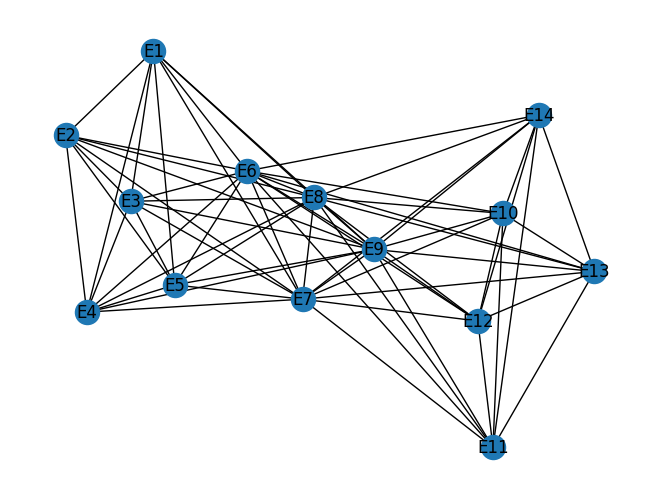

In [52]:
nx.draw(E, with_labels=True)

A plot of the projected women's network:

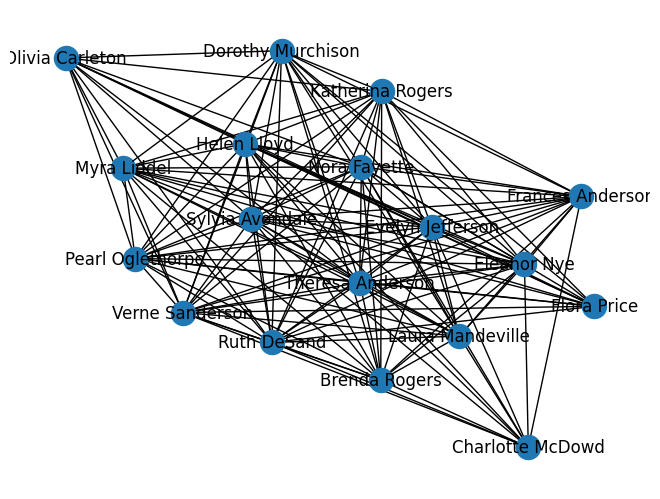

In [53]:
nx.draw(W, with_labels=True)

A bipartite network of attendees and events:

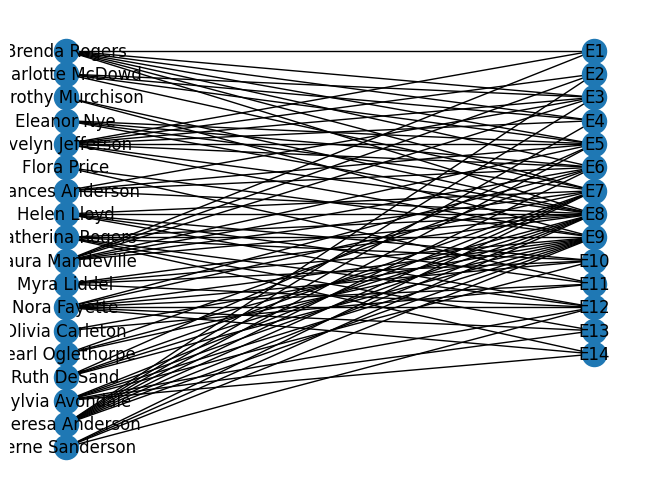

In [54]:
events = sorted(
    [n for n,d in B.nodes(data=True) if d['bipartite'] == 1],
    key = lambda x: int(x[1:])
)

women = [n for n,d in B.nodes(data=True) if d['bipartite'] == 0]

women_sorted = sorted(women)

pos = {}

for i, women in enumerate(women_sorted):
    pos[women] = (0, -i)

for i , event in enumerate(events):
    pos[event] = (1, -i)

nx.draw(B, pos, with_labels=True)

## Conclusions

The Southern Club Women data highlights an interesting set of interactions among this group of women. The group of women existed essentially as two mostly separate communities that interacted through three main events (E7, E8, E9). Additionally, the women appear to be socially connected through two primary attendees: Evelyn Jefferson and Nora Fayette. Each of these women attended the majority of their individual community events as well as the most of the major events that brought the two communities together.